# Groove study
## Imports

In [3]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder

from default_path import PathHandler
import bin_ratings as br
import compute_CLAP_embeddings as clap_embed
import groove_sentences
import zero_shot_estimation

paths = PathHandler("axel") # "nicolas" # Normalement, tu as juste à changer ton nom, et à ajouter tes paths dans le fichier default_path.py.
audio_folder_path = paths.get_path_audio_folder() # Si tu as rentré le chemin vers tes données audios dans la variable dans default_path, ça devrait tourner tout seul !

## Study parameters

In [ ]:
# Parameters for the experiments
checkpoint_name = "laion/larger_clap_music" # larger_clap_music # larger_clap_general # larger_clap_music_and_speech # clap-htsat-unfused

groove_keys = ['dance', 'listen', 'party','groove']
groove_embeddings_keyword = "objective"

## Annotations

In [5]:

# Load all the groove data, with groove ratings according to the song ID
groove_study_dataframe = pd.read_excel(paths.get_path_groove_xls())
groove_study_dataframe = br.add_groove_binned_columns(groove_study_dataframe, k=groove_sentences.hierarchy_level) # hierarchy_level = 3
print(f"Groove study dataframe columns: {groove_study_dataframe.columns}")

# grooveratings = [groove_study_dataframe[groove_study_dataframe['id']==currentid]['groove'] for currentid in song_ids]
# style_family = LabelEncoder().fit_transform([groove_study_dataframe[groove_study_dataframe['id']==currentid]['style_family'] for currentid in song_ids])
# style = LabelEncoder().fit_transform([groove_study_dataframe[groove_study_dataframe['id']==currentid]['style'] for currentid in song_ids])
# tempo = [groove_study_dataframe[groove_study_dataframe['id']==currentid]['tempo'] for currentid in song_ids]

Groove study dataframe columns: Index(['artist', 'song', 'style_family', 'style', 'groove', 'Q1_dance',
       'Q2_listen', 'Q3_beat', 'Q4_party', 'Q5_rhythm', 'Q6_disturbing', 'id',
       'video_type', 'recording_year', 'drummer', 'start', 'end', 'duration',
       'tempo', 'tempo_change', 'residual_microtiming', 'swing_ratio_8',
       'swing_ratio_16', 'mean_IOI', 'beat_salience_original_recording',
       'dyn_range_original_recording', 'centroid_original_recording',
       'stereo_spread_original_recording', 'beat_salience_reconstruction',
       'dyn_range_reconstruction', 'centroid_reconstruction',
       'stereo_spread_reconstruction', 'number_of_events',
       'number_of_distinct_events', 'syncopation', 'rhythmic_periodicity',
       'rhythmic_variability', 'pulse', 'backbeat', 'downbeat',
       'pattern_category', 'Q1_dance-binned', 'Q2_listen-binned',
       'Q3_beat-binned', 'Q4_party-binned', 'Q5_rhythm-binned',
       'Q6_disturbing-binned', 'groove-binned'],
      dty

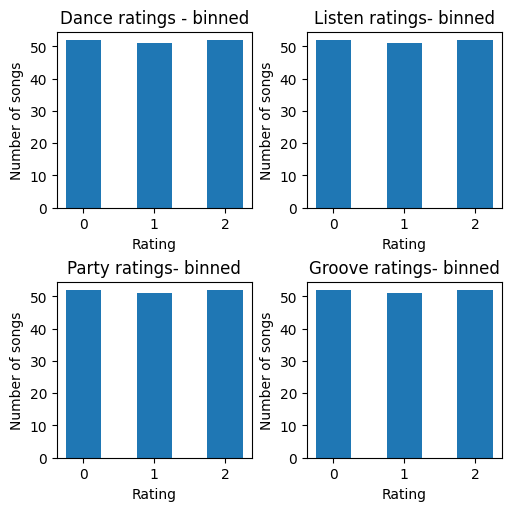

In [53]:
fig, axs = plt.subplots(1,4, constrained_layout=True, figsize = (10,2))
# fig, axs = plt.subplots(2,2, constrained_layout=True,figsize = (5,5))
# plt.subplots_adjust(left=1, bottom=None, right=1, top=None, wspace=None, hspace=None)
axs.flat[0].hist(groove_study_dataframe['Q1_dance-binned'], bins = [0,0.5,1,1.5,2,2.5], align='left')
axs.flat[0].title.set_text("Dance ratings - binned")
axs.flat[1].hist(groove_study_dataframe['Q2_listen-binned'], bins = [0,0.5,1,1.5,2,2.5], align='left')
axs.flat[1].title.set_text("Listen ratings- binned")
axs.flat[2].hist(groove_study_dataframe['Q4_party-binned'], bins = [0,0.5,1,1.5,2,2.5], align='left')
axs.flat[2].title.set_text("Party ratings- binned")
axs.flat[3].hist(groove_study_dataframe['groove-binned'], bins = [0,0.5,1,1.5,2,2.5], align='left')
axs.flat[3].title.set_text("Groove ratings- binned")
for ax in axs.flat:
    ax.set(xlabel='Rating', ylabel='Number of songs')
plt.savefig("annotations_binned_groove_study_histograms_inline.png")
plt.show()


In [22]:
axs.flat

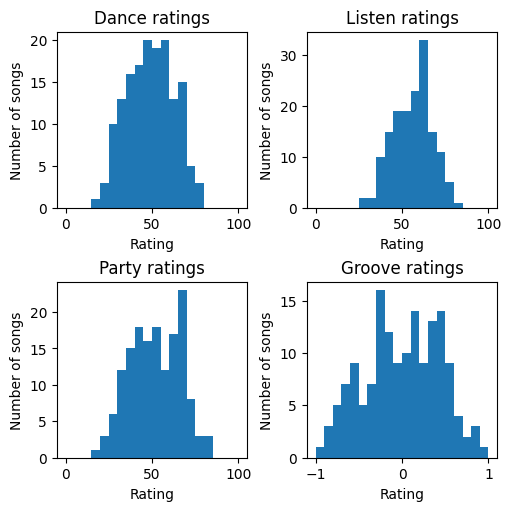

In [45]:
# fig, axs = plt.subplots(1,4, constrained_layout=True, figsize = (10,2))
fig, axs = plt.subplots(2,2, constrained_layout=True,figsize = (5,5))
# plt.subplots_adjust(left=1, bottom=None, right=1, top=None, wspace=None, hspace=None)
axs.flat[0].hist(groove_study_dataframe['Q1_dance'], bins = range(0, 101, 5))
axs.flat[0].title.set_text("Dance ratings")
axs.flat[1].hist(groove_study_dataframe['Q2_listen'], bins = range(0, 101, 5))
axs.flat[1].title.set_text("Listen ratings")
axs.flat[2].hist(groove_study_dataframe['Q4_party'], bins = range(0, 101, 5))
axs.flat[2].title.set_text("Party ratings")
axs.flat[3].hist(groove_study_dataframe['groove'], bins = np.arange(-1, 1.1, 0.1))
axs.flat[3].title.set_text("Groove ratings")
for ax in axs.flat:
    ax.set(xlabel='Rating', ylabel='Number of songs')
plt.savefig("annotations_groove_study_histograms.png")
plt.show()


## Embeddings
### Song embeddings

In [6]:
song_embeddings, song_list = clap_embed.get_audio_embeddings(audio_folder_path, checkpoint_name) # Compute and save the audio embeddings.
song_ids = [song_list[i].split('.m4a')[0][-12:-1] for i in range(len(song_list))]

print(f"Number of audio embeddings: {len(song_embeddings)}") # audio_embeddings is a dictionary of embeddings, with the id as key
print(f"Size of an audio embeddings: {song_embeddings[song_ids[0]].shape}") # audio_embeddings is a dictionary of embeddings, with the id as key

# Restricting the dataset to the actual audio we have embeddings for
groove_study_dataframe = groove_study_dataframe[groove_study_dataframe['id'].isin(song_ids)]

100%|██████████| 148/148 [00:00<00:00, 5030.04it/s]

Number of audio embeddings: 148
Size of an audio embeddings: (1, 512)


In [7]:
# Compute embeddings
sentences_embeddings = clap_embed.embed_groove_encodings(groove_keys, groove_embeddings_keyword, checkpoint_name, verbose=True)
print(f"Number of keys: {len(sentences_embeddings)}")
print(f"Size of an objective sentence embeddings: {sentences_embeddings[groove_keys[0]].shape}")

  0%|          | 0/4 [00:00<?, ?it/s]

Processing dance, with the following sentences: ['A music that is not danceable', 'A music that is danceable', 'A music that is very danceable']


100%|██████████| 4/4 [00:00<00:00,  6.54it/s]

Processing listen, with the following sentences: ['A music that is not enjoyable to listen to', 'A music that is enjoyable to listen to', 'A music that is very enjoyable to listen to']
Processing party, with the following sentences: ['A music that is not at all suited for a party', 'A music that is somewhat suited for a party', 'A music that is perfectly suited for a party']
Processing groove, with the following sentences: ['A music that is not groovy', 'A music that is somewhat groovy', 'A music that is very groovy']
Number of keys: 4
Size of an objective sentence embeddings: (3, 512)


In [8]:
print(f"Computing groove evaluation with parameters:\n\t checkpoint_name: {checkpoint_name}\n\t text_embeddings_keyword: {groove_embeddings_keyword}")

estimated_groove_ratings, groove_error, groove_accuracy = zero_shot_estimation.compute_groove_evaluation(song_embeddings, sentences_embeddings, song_ids, groove_study_dataframe, groove_keys)

# for idx, key in enumerate(groove_keys):
#     print(f"Average estimation error for {key}: {np.mean(groove_error, axis=0)[idx]}")

for idx, key in enumerate(groove_keys):
    print(f"Average accuracy for {key}: {np.mean(groove_accuracy, axis=0)[idx]}")

# Je t'ai quand même créé un tableau pandas, si tu as plus l'habitude de travailler avec.
groove_accuracy_pandas = pd.DataFrame({'id': song_ids})
for idx_gk, groove_key in enumerate(groove_keys):
    groove_accuracy_pandas.insert(idx_gk + 1, groove_key, groove_accuracy[:,idx_gk])

groove_accuracy_pandas

Computing groove evaluation with parameters:
	 checkpoint_name: laion/larger_clap_music
	 text_embeddings_keyword: objective
Average accuracy for dance: 0.32432432432432434
Average accuracy for listen: 0.35135135135135137
Average accuracy for party: 0.32432432432432434
Average accuracy for groove: 0.32432432432432434


,id,dance,listen,party,groove
0,8iwBM_YB1sE,0.0,0.0,0.0,0.0
1,pUSpBAmSMb8,1.0,1.0,1.0,1.0
2,pvJH0x1CTho,0.0,0.0,0.0,0.0
3,JnfyjwChuNU,1.0,1.0,0.0,1.0
4,0qanF-91aJo,1.0,0.0,0.0,0.0
...,...,...,...,...,...
143,MUaL1FnotRQ,1.0,1.0,0.0,0.0
144,lSUk8bSVHYc,1.0,0.0,1.0,1.0
145,fG2seugAgnU,0.0,1.0,1.0,1.0
146,7km4EHgkQiw,0.0,0.0,0.0,0.0


In [9]:
accuracies = zero_shot_estimation.baseline_dummy_classifier(groove_study_dataframe, groove_keys)

print("Results for the dummy classifier:")
for idx, key in enumerate(groove_keys):
    print(f"Average accuracy for {key}: {accuracies[idx]}")

Results for the dummy classifier:
Average accuracy for dance: 0.34459459459459457
Average accuracy for listen: 0.33783783783783783
Average accuracy for party: 0.34459459459459457
Average accuracy for groove: 0.33783783783783783


In [10]:
dummy_accuracies = zero_shot_estimation.baseline_dummy_classifier(groove_study_dataframe, groove_keys)
results  = [dummy_accuracies]
text_conditions = ["dummy classifier"]

for groove_embeddings_keyword in ["objective", "subjective", "chatGPT"]:
    sentences_embeddings = clap_embed.embed_groove_encodings(groove_keys, groove_embeddings_keyword, checkpoint_name, verbose=False)
    for checkpoint_name in ["laion/larger_clap_music", "laion/larger_clap_general", "laion/larger_clap_music_and_speech", "laion/clap-htsat-unfused"]:
        song_embeddings, song_list = clap_embed.get_audio_embeddings(audio_folder_path, checkpoint_name) # Compute and save the audio embeddings.
        
        # print(f"Computing groove evaluation with parameters:\n\t checkpoint_name: {checkpoint_name}\n\t text_embeddings_keyword: {groove_embeddings_keyword}")
        estimated_groove_ratings, groove_error, groove_accuracy = zero_shot_estimation.compute_groove_evaluation(song_embeddings, sentences_embeddings, song_ids, groove_study_dataframe, groove_keys)
        # for idx, key in enumerate(groove_keys):
        #     print(f"Average accuracy for {key}: {np.mean(groove_accuracy, axis=0)[idx]}")
        results.append(np.mean(groove_accuracy, axis=0))
        text_conditions.append(f"{checkpoint_name} - {groove_embeddings_keyword}")
        # print("\n")

dataframe = pd.DataFrame(results, columns=groove_keys, index=text_conditions)
display(dataframe.style.bar(color='#5fba7d'))


100%|██████████| 148/148 [00:00<00:00, 4891.59it/s]


,dance,listen,party,groove
dummy classifier,0.344595,0.337838,0.344595,0.337838
laion/larger_clap_music - objective,0.324324,0.351351,0.324324,0.324324
laion/larger_clap_general - objective,0.385135,0.398649,0.351351,0.439189
laion/larger_clap_music_and_speech - objective,0.324324,0.371622,0.364865,0.405405
laion/clap-htsat-unfused - objective,0.270270,0.344595,0.317568,0.378378
laion/larger_clap_music - subjective,0.358108,0.337838,0.331081,0.331081
laion/larger_clap_general - subjective,0.331081,0.358108,0.371622,0.317568
laion/larger_clap_music_and_speech - subjective,0.479730,0.439189,0.351351,0.324324
laion/clap-htsat-unfused - subjective,0.378378,0.317568,0.452703,0.439189
laion/larger_clap_music - chatGPT,0.310811,0.331081,0.358108,0.304054
